In [1]:
import os
os.chdir('../../..')

In [2]:
from src.datasets import QM9Dataset

In [4]:
import re

import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns
import pandas as pd

from rdkit import Chem
from rdkit.Chem import Draw
from collections import Counter
from scipy.stats import ks_2samp

from torch_geometric.datasets import QM9

In [4]:
outliers = pl.read_parquet('data/QM9/outliers/synthetic_outliers.parquet')

In [5]:
qm9 = QM9Dataset(limit=None)
df = qm9.load(force_process=False)

2026-06-13 12:53:58.132 | INFO     | src.datasets:_load_full_qm9_df:935 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-06-13 12:53:58.588 | INFO     | src.datasets:_sample_qm9_df:1119 - QM9 sampling complete: strategy=stratified, requested_limit=None, returned_rows=121222, sampling on columns=['num_atoms', 'gap'].


In [10]:
import numpy as np
import polars as pl
from rdkit import Chem
from rdkit.Geometry import Point3D
from rdkit.Chem import rdDetermineBonds, rdMolTransforms
from tqdm import tqdm
from loguru import logger

def append_geometric_strain(df: pl.DataFrame) -> pl.DataFrame:
    """
    Computes the Geometric Valence Angle Strain Index post-load.
    Guarantees structural shape handling and safe RDKit property execution.
    """
    required = {"atomic_numbers", "coordinates"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"DataFrame is missing required columns: {missing}")

    atoms_series = df["atomic_numbers"].to_list()
    coords_series = df["coordinates"].to_list()
    
    ideal_angles = {
        Chem.HybridizationType.SP3: 109.47,
        Chem.HybridizationType.SP2: 120.0,
        Chem.HybridizationType.SP: 180.0
    }
    
    strain_scores = []
    failed_count = 0

    logger.info(f"Computing geometric valence angle strain for {len(df)} rows...")
    
    for atoms, coords in tqdm(zip(atoms_series, coords_series), total=len(df), desc="Calculating Strain"):
        if atoms is None or coords is None or len(atoms) == 0:
            strain_scores.append(None)
            continue
            
        try:
            # Force shape mapping to handle (N, 3) matrix bounds safely
            coords_np = np.array(coords, dtype=np.float64).reshape(-1, 3)
            
            if len(atoms) != coords_np.shape[0]:
                strain_scores.append(None)
                continue

            # Build structural object from cache layers
            mol = Chem.RWMol()
            for z in atoms:
                mol.AddAtom(Chem.Atom(int(z)))
            
            conf = Chem.Conformer(len(atoms))
            for idx in range(len(atoms)):
                pos = coords_np[idx]
                conf.SetAtomPosition(idx, Point3D(pos[0], pos[1], pos[2]))
            mol.AddConformer(conf)
            
            # Reverse-engineer explicit bonds from DFT coordinate dimensions
            rdDetermineBonds.DetermineBonds(mol, charge=0)
            
            # Recalculate valence caches safely
            mol.UpdatePropertyCache(strict=False)
            
            total_deviation = 0.0
            angle_count = 0
            
            # Compute intensive angle metrics across local triplets
            for j in range(mol.GetNumAtoms()):
                atom_j = mol.GetAtomWithIdx(j)
                hybrid = atom_j.GetHybridization()
                ideal = ideal_angles.get(hybrid, 109.47)
                
                neighbors = [bond.GetOtherAtomIdx(j) for bond in atom_j.GetBonds()]
                n_neighbors = len(neighbors)
                if n_neighbors < 2:
                    continue
                    
                for idx_a in range(n_neighbors):
                    for idx_b in range(idx_a + 1, n_neighbors):
                        at_i = neighbors[idx_a]
                        at_k = neighbors[idx_b]
                        
                        angle = rdMolTransforms.GetAngleDeg(conf, at_i, j, at_k)
                        total_deviation += (angle - ideal) ** 2
                        angle_count += 1
                        
            score = float(total_deviation / angle_count) if angle_count > 0 else 0.0
            strain_scores.append(score)
            
        except Exception:
            failed_count += 1
            strain_scores.append(None)

    if failed_count > 0:
        logger.warning(
            f"Failed to resolve stable configurations for {failed_count} molecules "
            f"({(failed_count / len(df)) * 100:.2f}% of dataset). Column populated with None."
        )

    return df.with_columns(pl.Series("geometric_strain", strain_scores, dtype=pl.Float64))

In [11]:
df = append_geometric_strain(df)

2026-06-09 11:12:01.035 | INFO     | __main__:append_geometric_strain:31 - Computing geometric valence angle strain for 124232 rows...
Calculating Strain: 100%|██████████| 124232/124232 [00:35<00:00, 3536.07it/s]
2026-06-09 11:12:36.171 | WARNING  | __main__:append_geometric_strain:94 - Failed to resolve stable configurations for 3010 molecules (2.42% of dataset). Column populated with None.


In [12]:
df['formula', 'geometric_strain']

formula,geometric_strain
str,f64
"""CH4""",0.000005
"""H3N""",16.326399
"""H2O""",33.146867
"""C2H2""",0.0
"""CHN""",0.000011
…,…
"""C7H12N2+2""",375.276466
"""C8H11N""",null
"""C6H10N2O+2""",416.944969


In [13]:
df_planar = df.filter(pl.col('pbf_score') < 0.1)
df_planar['smiles']

smiles
str
"""[H]O[H]"""
"""[H]C#C[H]"""
"""[H]C#N"""
"""[H]C([H])=O"""
"""[H]C(=O)N([H])[H]"""
…
"""O=C1N=C(F)C(F)=NO1"""
"""[H][N-]C1=[N+]([H])C(=O)ON=C1F"""
"""[H][N-]C1=C(F)NOC(=O)O1"""


In [17]:
import py3Dmol
from rdkit import Chem
from rdkit.Chem import AllChem


def visualize_smiles_3d(smiles: str):
    """Takes a SMILES string, generates 3D coordinates, and visualizes it."""
    # 1. Parse the SMILES string
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        print(f"Error: Invalid SMILES string '{smiles}'")
        return

    # 2. Add explicit hydrogens (crucial for accurate 3D geometry)
    mol = Chem.AddHs(mol)

    # 3. Embed the molecule to generate 3D coordinates
    # ETKDGv3 is the standard algorithm for high-quality 3D conformations
    params = AllChem.ETKDGv3()
    embed_status = AllChem.EmbedMolecule(mol, params)

    if embed_status == -1:
        print("Warning: Initial 3D embedding failed. Trying fallback...")
        # Fallback to older embedding if standard fails
        AllChem.EmbedMolecule(mol, enforceChirality=False)

    # 4. Optimize the geometry using the MMFF94 force field
    try:
        AllChem.MMFFOptimizeMolecule(mol)
    except Exception:
        print("Warning: MMFF94 optimization failed. Displaying unoptimized geometry.")

    # 5. Convert the RDKit molecule to a block of mol data for py3Dmol
    mol_block = Chem.MolToMolBlock(mol)

    # 6. Render the 3D visualization
    viewer = py3Dmol.view(width=600, height=400)
    viewer.addModel(mol_block, "mol")

    # Styling: 'stick' representation shows bonds clearly; can also use 'sphere'
    viewer.setStyle({"stick": {}, "sphere": {"scale": 0.3}})

    viewer.zoomTo()
    return viewer.show()


# --- Example Usage ---
# Using Caffeine as an example
caffeine_smiles = "CN1C=NC2=C1C(=O)N(C(=O)N2C)C"
visualize_smiles_3d(df_planar['smiles'][780])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [9]:
qm9_df = QM9(root='data/QM9/raw')

Processing...
100%|██████████| 133885/133885 [00:30<00:00, 4365.24it/s]
Done!
/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_9554/1148355640.py:1: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  qm9_df = QM9(root='data/QM9/raw').data


In [14]:
qm9_df

Data(x=[2359210, 11], edge_index=[2, 4883516], edge_attr=[4883516, 4], y=[130831, 19], pos=[2359210, 3], z=[2359210], smiles=[130831], name=[130831], idx=[130831])

In [ ]:
print(len(df['coordinates'].to_list()[0]))

5


In [ ]:
df.filter(pl.col("num_atoms") != pl.col("coordinates").list.len())['num_atoms', 'coordinates']

num_atoms,coordinates
i64,list[list[f64]]
10,"[[0.681, 0.0, 0.0], [-0.681, 0.0, 0.0], … [2.9496, 0.0, 0.0]]"
10,"[[0.0151, 0.0, 1.0], [1.3823, 0.0, 1.0], … [2.543, 0.0, 1.0]]"
12,"[[-0.0528, 1.4742, 0.01], [0.0194, 0.0219, 0.0633], … [0.3701, -1.4402, 1.6223]]"
13,"[[-0.0916, 1.3754, -0.0073], [-0.0696, -0.0483, -0.1115], … [1.835, -0.361, -2.5849]]"
11,"[[-0.0445, 1.2562, 0.3168], [-0.0391, 0.0491, -0.0167], … [0.0695, -2.2542, -1.618]]"
…,…
21,"[[0.7698, -0.1784, -0.1875], [2.2453, 0.0097, -0.0872], … [4.4917, 2.6306, -0.5829]]"
20,"[[0.9166, -0.1341, -0.4725], [2.3932, -0.3257, -0.3523], … [2.9144, -1.8683, -2.0441]]"
19,"[[0.8185, -0.554, 0.0062], [2.1363, -0.2599, -0.0193], … [4.2513, 2.4444, -0.6506]]"


# Visualization of a few molecules
- Ensuring that SMILES works for generating unique identifiers for each molecule

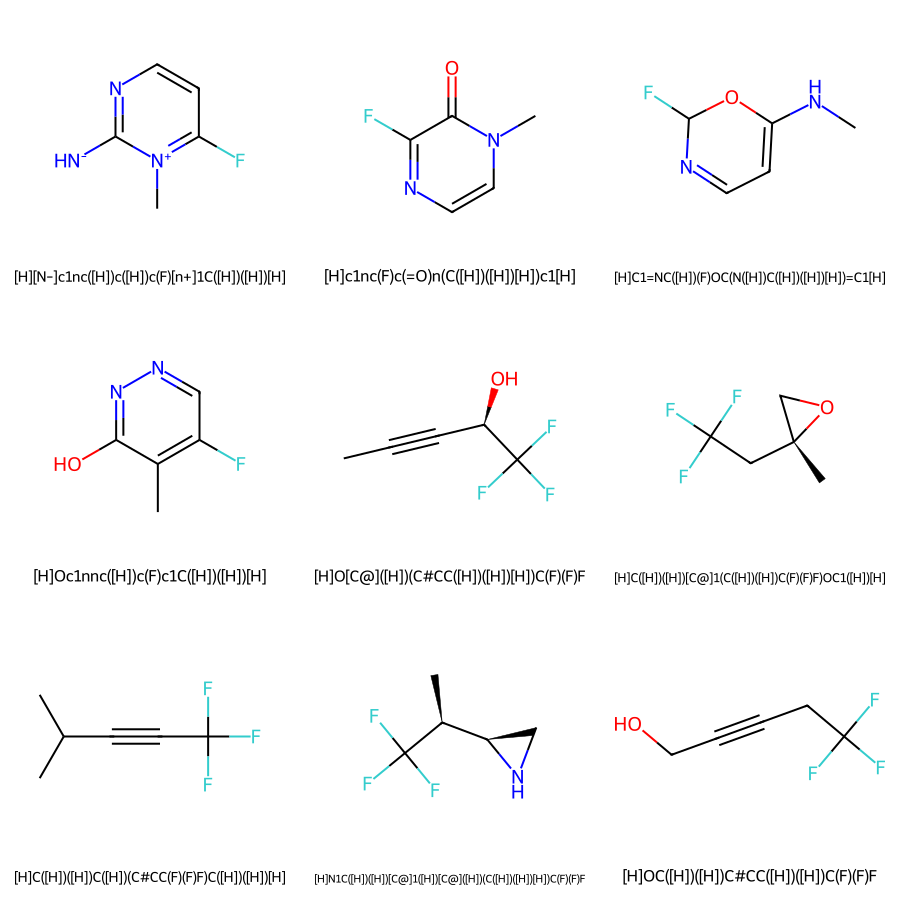

In [ ]:
sample_smiles = df.tail(9)["canonical_smiles"].to_list()
mols = [Chem.MolFromSmiles(s) for s in sample_smiles]

img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(300, 300), legends=sample_smiles)
img

# Figures for report

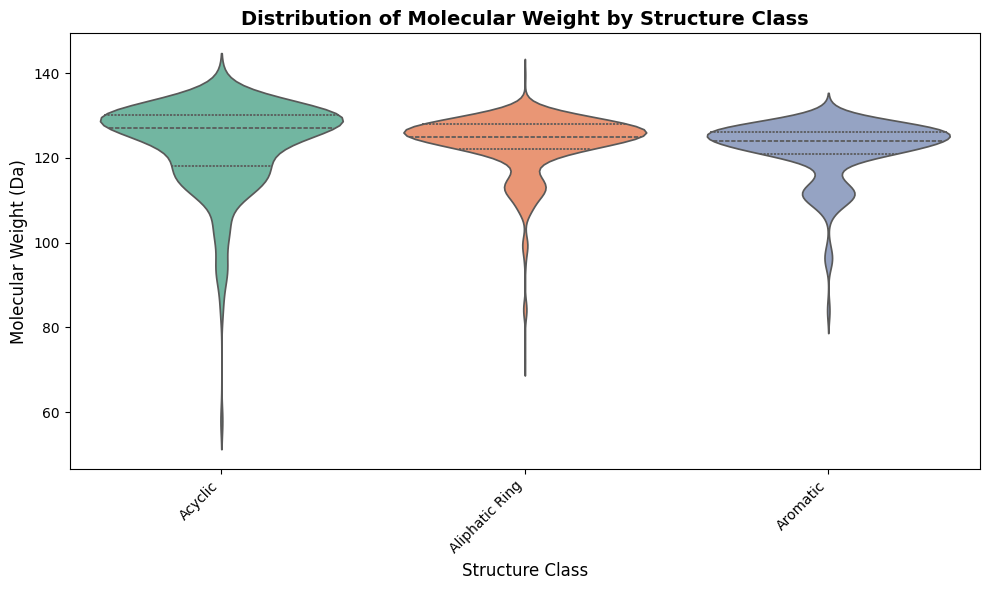

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df, 
    x='structure_class', 
    y='mol_weight', 
    palette='Set2', 
    hue='structure_class',
    inner='quartile'
)
plt.title('Distribution of Molecular Weight by Structure Class', fontsize=14, fontweight='bold')
plt.xlabel('Structure Class', fontsize=12)
plt.ylabel('Molecular Weight (Da)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('figures/qm9/analysis/distribution_by_structure_class.png', dpi=300)
plt.show()

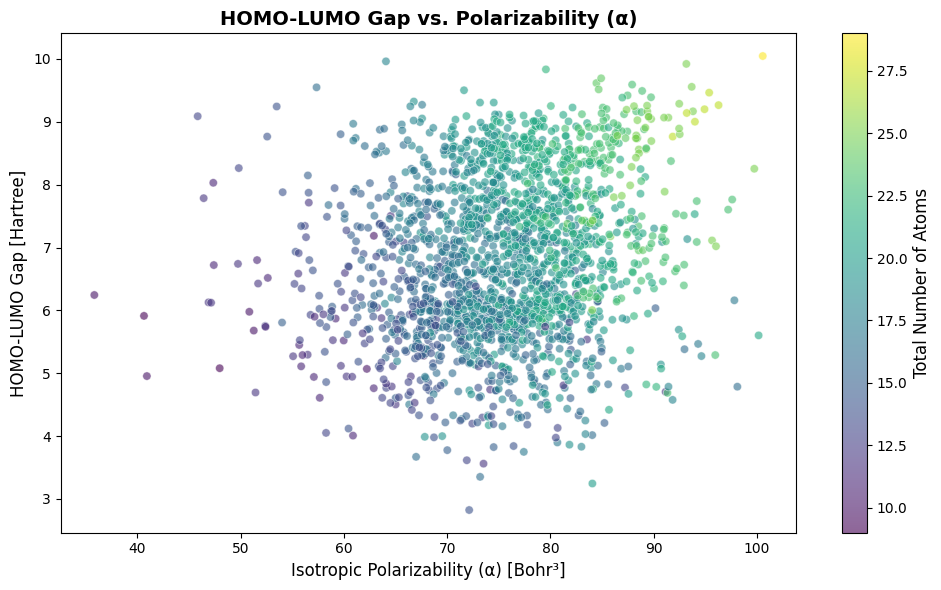

In [ ]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df['alpha'], 
    df['gap'], 
    c=df['num_atoms'], 
    cmap='viridis', 
    alpha=0.6,
    edgecolors='w',
    linewidth=0.5
)
cbar = plt.colorbar(scatter)
cbar.set_label('Total Number of Atoms', fontsize=12)

plt.title('HOMO-LUMO Gap vs. Polarizability (α)', fontsize=14, fontweight='bold')
plt.xlabel('Isotropic Polarizability (α) [Bohr³]', fontsize=12)
plt.ylabel('HOMO-LUMO Gap [eV]', fontsize=12)
plt.tight_layout()
plt.show()

In [11]:
df.columns

['mol_id',
 'formula',
 'smiles',
 'canonical_smiles',
 'scaffold_smiles',
 'generic_scaffold',
 'root_scaffold',
 'brics_fragments',
 'scaffold_tree_nodes',
 'selfies',
 'functional_groups',
 'structure_class',
 'is_injected',
 'outlier_category',
 'mol_weight',
 'logp',
 'tpsa',
 'election_affinity',
 'ionization_energies',
 'num_heavy_atoms',
 'num_rings',
 'num_aromatic_rings',
 'num_fluorine',
 'num_heteroatoms',
 'num_atoms',
 'coordination',
 'num_rotatable_bonds',
 'fraction_csp1',
 'fraction_csp2',
 'fraction_csp3',
 'h_bond_donors',
 'h_bond_acceptors',
 'branching_index',
 'num_sp_carbons',
 'num_sp2_carbons',
 'num_sp3_carbons',
 'main_chain_length',
 'raw_token_count',
 'avg_bond_length',
 'fr_benzene',
 'fr_alcohol',
 'fr_phenol',
 'fr_amine',
 'fr_amide',
 'fr_carboxylic_acid',
 'fr_ester',
 'fr_ketone',
 'fr_ether',
 'fr_nitro',
 'pbf_score',
 'coordinates',
 'atomic_numbers',
 'mu',
 'alpha',
 'homo',
 'lumo',
 'gap',
 'r2',
 'zpve',
 'u0',
 'u',
 'h',
 'g',
 'cv',
 'u

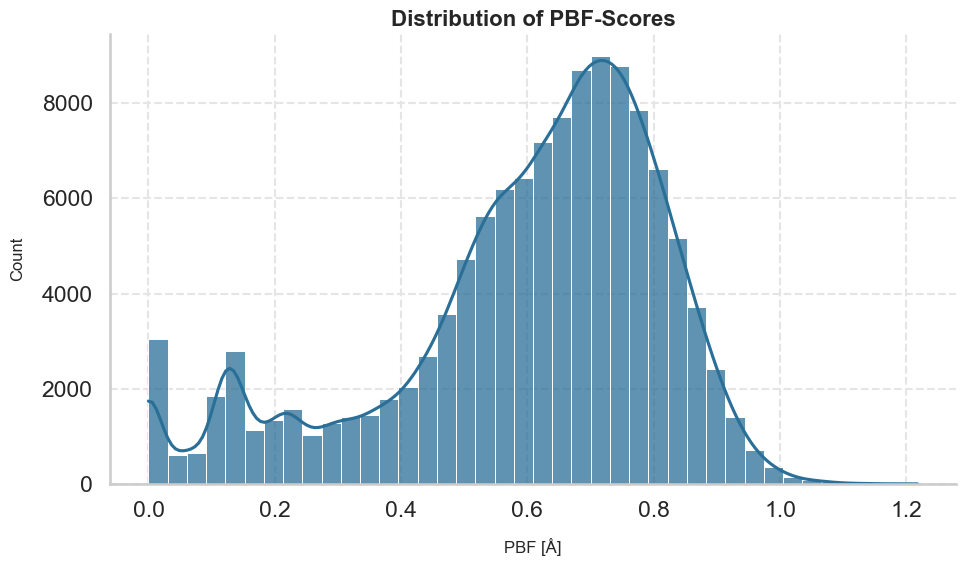

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, professional base style
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'grid.color': '#E5E5E5',
    'grid.linestyle': '--'
})

# Initialize canvas
fig, ax = plt.subplots(figsize=(10, 6))

# Create the distribution plot (Histogram + Smooth KDE curve)
sns.histplot(
    data=df,
    x='pbf_score',
    kde=True,
    color='#2a6f97',       # A professional muted blue
    edgecolor='white',
    linewidth=0.7,
    alpha=0.75,
    bins=40,
    ax=ax
)

# Clean up axes (remove top and right spines)
sns.despine(ax=ax, top=True, right=True)

# Refine titles and labels
ax.set_title('Distribution of PBF-Scores', 
             fontsize=16, fontweight='bold')
ax.set_xlabel('PBF [Å]', fontsize=12, labelpad=12)
ax.set_ylabel('Count', fontsize=12, labelpad=12)

# Save and show
plt.tight_layout()
# Optional: plt.savefig('figures/qm9/analysis/plot_homo_lumo_gap_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
print(len(df.filter(pl.col("pbf_score") < 0.1)))

4415


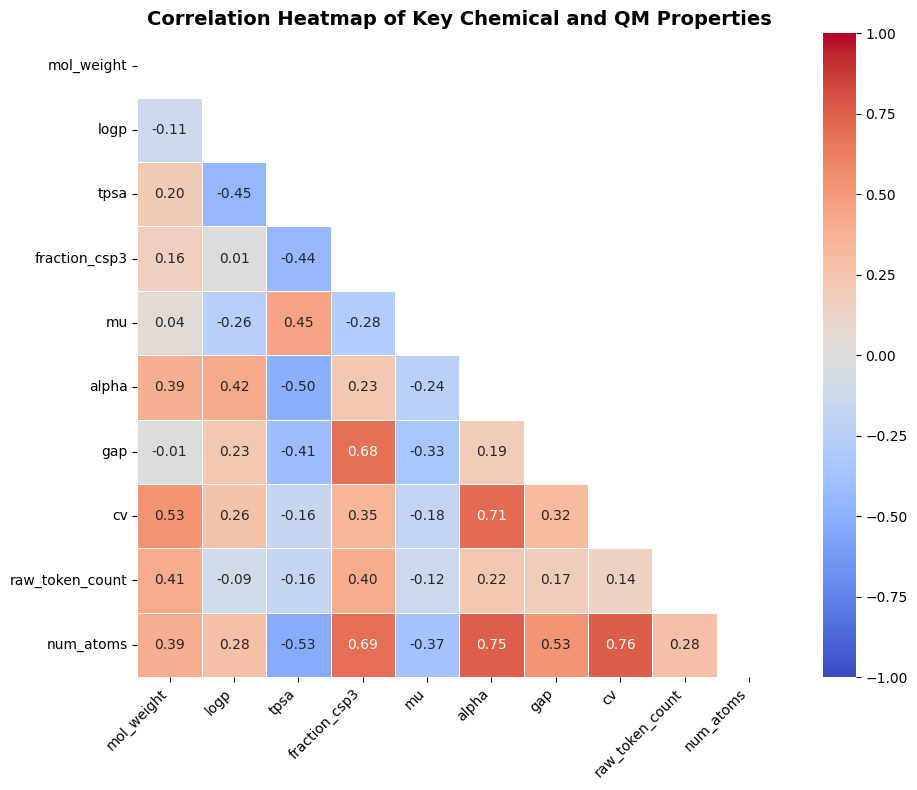

In [6]:
plt.figure(figsize=(10, 8))

# Select a mix of 2D cheminformatics features and 3D quantum features
features_of_interest = [
    'mol_weight', 'logp', 'tpsa',
    'fraction_csp3', 'mu', 'alpha', 'gap', 'cv', 'raw_token_count', 'num_atoms'
]

# Calculate Spearman correlation (better for potentially non-linear chemical features)
corr = df[features_of_interest].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1,
    square=True,
    xticklabels=features_of_interest,   # ← use names instead of 0,1,2…
    yticklabels=features_of_interest
)

plt.xticks(rotation=45, ha='right')      # if you want them tilted
plt.title('Correlation Heatmap of Key Chemical and QM Properties', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

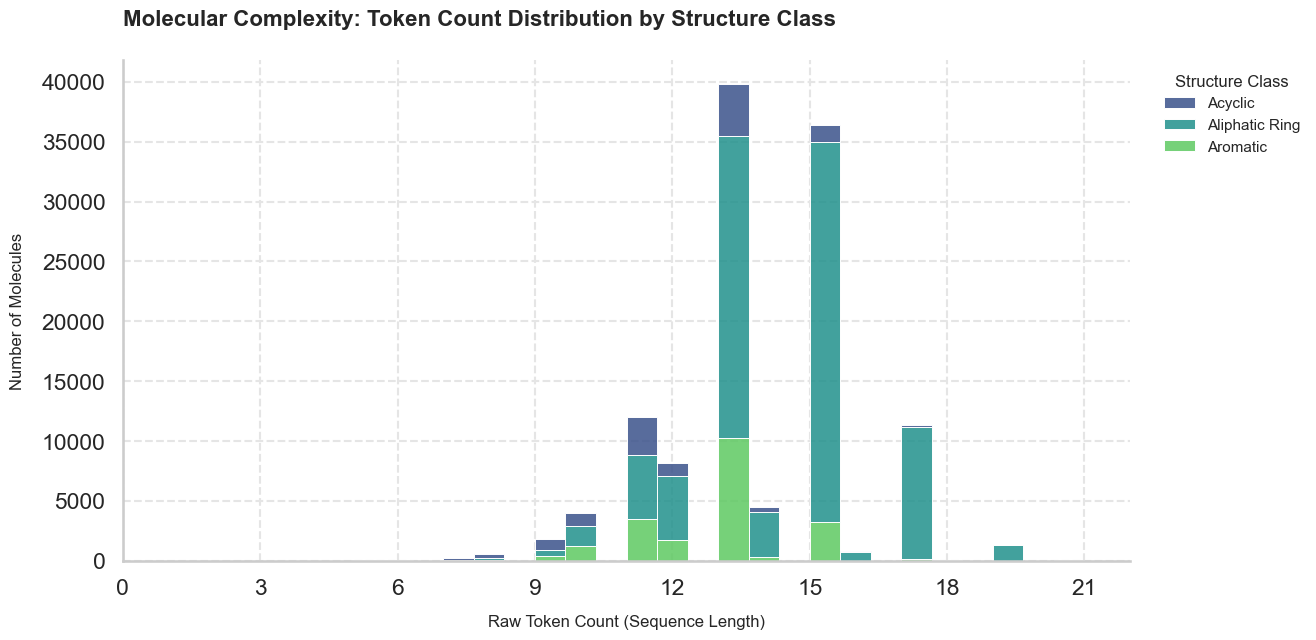

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker  
import seaborn as sns

# Set a clean, professional base style
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'grid.color': '#E5E5E5',
    'grid.linestyle': '--'
})

# Initialize canvas
fig, ax = plt.subplots(figsize=(13, 6.5))

# Create the plot
sns.histplot(
    data=df,
    x='raw_token_count',
    hue='structure_class',
    multiple='stack',
    palette='viridis',
    edgecolor='white',
    linewidth=0.7,
    alpha=0.85,
    bins=30,
    ax=ax
)

# 2. Force the X-axis to only use whole numbers (integers)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Clean up axes
sns.despine(ax=ax, top=True, right=True)

# Refine titles and labels
ax.set_title('Molecular Complexity: Token Count Distribution by Structure Class', 
             fontsize=16, fontweight='bold', pad=25, loc='left')
ax.set_xlabel('Raw Token Count (Sequence Length)', fontsize=12, labelpad=12)
ax.set_ylabel('Number of Molecules', fontsize=12, labelpad=12)

# Perfect the legend placement
sns.move_legend(
    ax, 
    loc="upper left", 
    bbox_to_anchor=(1.02, 1), 
    title='Structure Class',
    frameon=False,        
    title_fontsize=12,
    fontsize=11
)

# Save and show
# plt.savefig('figures/qm9/analysis/plot_token_count_distribution.png', 
#             dpi=300, 
#             bbox_inches='tight')
plt.show()

In [3]:
qm9 = QM9Dataset()
df = qm9.load()

2026-06-25 16:11:29.188 | INFO     | src.datasets:_load_full_qm9_df:935 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-06-25 16:11:29.598 | INFO     | src.datasets:_sample_qm9_df:1119 - QM9 sampling complete: strategy=stratified, requested_limit=None, returned_rows=121222, sampling on columns=['num_atoms', 'gap'].


In [6]:
print(df['atomic_numbers'])

shape: (121_222,)
Series: 'atomic_numbers' [list[i64]]
[
	[6, 1, … 1]
	[7, 1, … 1]
	[8, 1, 1]
	[6, 6, … 1]
	[6, 7, 1]
	…
	[6, 7, … 1]
	[8, 6, … 1]
	[6, 6, … 1]
	[6, 6, … 1]
	[8, 6, … 1]
]


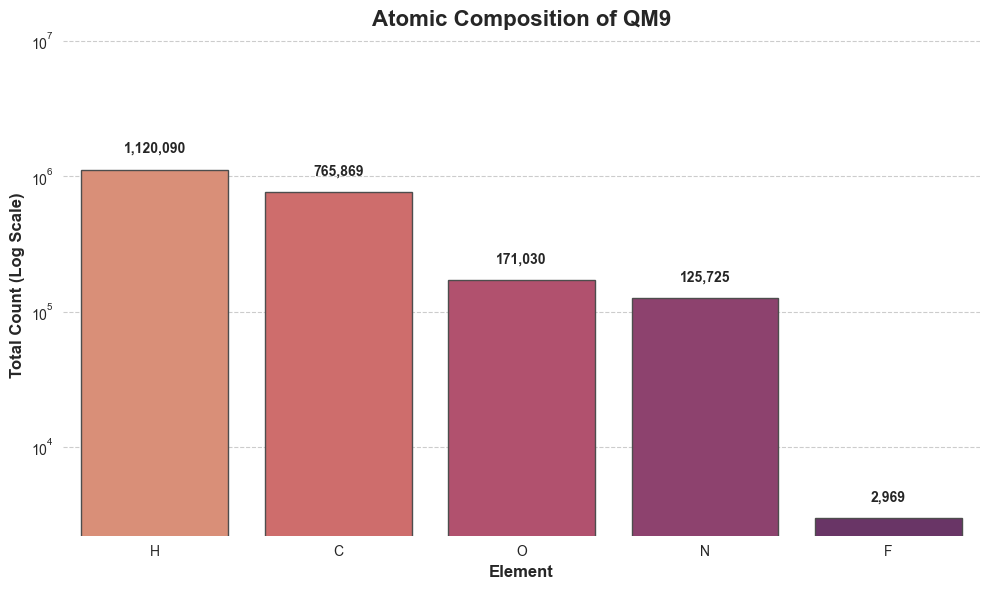

In [9]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Processing with Polars
# Keep the base mapping, but we will convert keys to strings for the expression
atomic_num_to_element = {1: "H", 6: "C", 7: "N", 8: "O", 9: "F"}
atomic_num_to_element_str = {str(k): v for k, v in atomic_num_to_element.items()}

comp_df = (
    df.select("atomic_numbers")
    .explode("atomic_numbers")
    .group_by("atomic_numbers")
    .len(name="Count")
    .with_columns(
        # Cast to String first, then map with string keys to avoid i64 coercion
        pl.col("atomic_numbers")
        .cast(pl.String)
        .replace(atomic_num_to_element_str)
        .alias("Element")
    )
    .select(["Element", "Count"])
    .sort("Count", descending=True)
    .to_pandas() # Convert to Pandas right at the boundary for Seaborn
)

# 2. Plotting (Preserving your exact visual layout)
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid", {'axes.grid' : True, 'grid.linestyle': '--'})

ax = sns.barplot(
    data=comp_df, 
    x='Element', 
    y='Count', 
    palette='flare',
    hue='Element',
    edgecolor='0.3',
    legend=False
)

ax.set_yscale("log")
plt.ylim(top=comp_df['Count'].max() * 10) # Room for labels

# Annotate values on top of the bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height):,}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 10), 
                    textcoords='offset points',
                    fontsize=10, fontweight='bold')

plt.title('Atomic Composition of QM9', fontsize=16, fontweight='bold')
plt.xlabel('Element', fontsize=12, fontweight='bold')
plt.ylabel('Total Count (Log Scale)', fontsize=12, fontweight='bold')
sns.despine(left=True, bottom=True)
plt.tight_layout()

# Save figure
plt.savefig('figures/qm9/analysis/atomic_composition.png', dpi=300, bbox_inches='tight')
plt.show()

# Average weight of molecule
- Also average bond length

In [ ]:
mol_weights = df['mol_weight']
print(np.average(mol_weights))

123.039


In [ ]:
mol_bond_lengths = df['avg_bond_length']
plotting = mol_bond_lengths.hist()
plotting

breakpoint,category,count
f64,cat,u32
1.212516,"""[1.200137, 1.212516]""",2
1.224895,"""(1.212516, 1.224895]""",35
1.237275,"""(1.224895, 1.237275]""",197
1.249654,"""(1.237275, 1.249654]""",354
1.262033,"""(1.249654, 1.262033]""",443
1.274412,"""(1.262033, 1.274412]""",454
1.286792,"""(1.274412, 1.286792]""",341
1.299171,"""(1.286792, 1.299171]""",119
1.31155,"""(1.299171, 1.31155]""",44


# Plot of scaffolds

In [ ]:
df['scaffold_smiles'].unique()

scaffold_smiles
str
"""O=C1COC2CCC12"""
"""C1OCC2OCC12"""
"""C1=CCC2(C1)CN2"""
"""C1C2CC3(CC3)C12"""
"""C1C[NH2+]CN1"""
…
"""c1cnoc1"""
"""C1OC2CC12"""
"""C1C2C3C2C2C1C32"""


# Similar Molecules for Grassmann stress test

In [ ]:
# from rdkit import Chem
# from rdkit.Chem import Draw
# import pandas as pd

# df = df.to_pandas()
# # Assuming your dataframe is named 'df'
# mol_ids = ["qm9_1237", "qm9_1244", "qm9_1246", "qm9_1248", "qm9_1474", "qm9_1476", "qm9_1478", "qm9_1486", "qm9_1447", "qm9_1449"]

# # FIX: Use boolean indexing instead of .filter()
# sample_smiles = df[df["mol_id"].isin(mol_ids)]["canonical_smiles"].tolist()

# # Generate molecules
# mols = [Chem.MolFromSmiles(s) for s in sample_smiles]

# # Create the grid image
# img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(300, 300), legends=sample_smiles)
# img

In [ ]:
qm9 = QM9Dataset(limit=10)
df = qm9.load()
df

2026-04-28 17:56:28.520 | INFO     | src.datasets:load:864 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-04-28 17:56:28.876 | INFO     | src.datasets:_sample_qm9_df:1064 - QM9 sampling complete: strategy=stratified, requested_limit=10, returned_rows=10.
2026-04-28 17:56:28.877 | INFO     | src.datasets:_add_requested_descriptors:202 - Applying requested QM9 descriptors to sampled dataframe (rows=10).
2026-04-28 17:56:28.877 | INFO     | src.datasets:_add_requested_descriptors:229 - No new descriptor columns added (already present or none requested).


mol_id,formula,smiles,canonical_smiles,scaffold_smiles,generic_scaffold,root_scaffold,brics_fragments,scaffold_tree_nodes,selfies,functional_groups,structure_class,is_injected,outlier_category,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,coordinates,atomic_numbers,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C
str,str,str,str,str,str,str,str,str,str,str,str,i64,str,i64,i64,i64,f64,f64,i64,i64,i64,i64,i64,i64,f64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,list[list[f64]],list[i64],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""qm9_3953""","""C4H8N2O2""","""[H]O/N=C(/C(=O)N([H])[H])C([H]…","""[H]O/N=C(/C(=O)N([H])[H])C([H]…","""Acyclic""","""Acyclic""","""Acyclic""","""[5*]N([H])[H],[1*]C(=O)/C(=N/O…","""""","""[H][O][/N][=C][Branch1][#Branc…","""amine,amide""","""Acyclic""",0,null,116,0,75,0.700266,13.133312,8,0,0,0,4,16,1.875,4,0.0,0.5,0.5,2,3,5,0,2,2,6,30,1.231653,0,0,0,1,1,0,0,0,0,0,"[[-0.0225, 1.6366, 0.0074], [-0.0369, 0.0965, 0.0456], … [-3.8986, -1.3419, 2.1078]]","[6, 6, … 1]",3.2707,65.160004,-6.854548,-1.034033,5.820516,1032.537476,3.509072,-11348.797852,-11348.545898,-11348.520508,-11349.744141,32.425999,-64.61306,-64.978134,-65.363663,-60.024677,2.62891,1.75955,1.14087
"""qm9_4358""","""C5H9N3""","""[H]C1=C(N([H])[H])N([H])C(C([H…","""[H]c1c(N([H])[H])c(C([H])([H])…","""c1cc[nH]c1""","""C1CCCC1""","""*1:*:*:*:*:1""","""[5*]N([H])[H],[14*]c1c([16*])c…","""[H]c1c(N([H])[H])c(C([H])([H])…","""[H][C][C][Branch1][=Branch1][N…","""amine""","""Aromatic""",0,null,111,0,67,0.523432,13.075867,8,1,1,0,3,17,2.0,3,0.0,0.8,0.2,3,2,8,0,4,1,6,33,1.225173,0,0,0,2,0,0,0,0,0,0,"[[0.0979, 1.5274, 0.1163], [0.0364, 0.0436, -0.0048], … [-0.1569, -0.519, 2.0452]]","[6, 6, … 1]",1.2195,73.169998,-4.476273,1.559212,6.035485,1020.88031,3.892616,-9798.09082,-9797.845703,-9797.820312,-9799.004883,32.366001,-70.349876,-70.759926,-71.171165,-65.448936,3.59985,1.67777,1.16224
"""qm9_7485""","""C4H7N3O""","""[H]N([H])C1=NC([H])([H])C([H])…","""[H]N([H])C1=NC([H])([H])C([H])…","""O=C1CCN=CN1""","""CC1CCCCC1""","""*=*1***=**1""","""[H]N([H])C1=NC([H])([H])C([H])…","""[H]N([H])C1=NC([H])([H])C([H])…","""[H][N][Branch1][C][H][C][=N][C…","""amine,amide""","""Aliphatic Ring""",0,null,113,-1,67,0.50593,13.163376,8,1,0,0,4,15,2.0,0,0.0,0.5,0.5,2,3,6,0,2,2,6,29,1.25515,0,0,0,1,1,0,0,0,0,0,"[[0.0295, 1.3487, 0.17], [-0.0771, -0.0256, 0.0063], … [2.0011, -0.1857, 0.2559]]","[7, 6, … 1]",2.5412,64.110001,-6.432771,-0.076192,6.35658,899.716492,3.315626,-10776.912109,-10776.720703,-10776.695312,-10777.759766,26.990999,-63.649151,-64.035774,-64.395592,-59.25008,3.51137,1.92659,1.29326
"""qm9_50061""","""C6H7NO2""","""[H]C(=O)N([H])[C@@]12C([H])([H…","""[H]C(=O)N([H])[C@@]12C([H])([H…","""C1C2OC3C1C23""","""C1C2CC3C1C23""","""*1*2**3*1*23""","""[1*]C([H])=O,[15*][C@@]12C([H]…","""[H]C(=O)N([H])[C@@]12C([H])([H…","""[H][C][=Branch1][C][=O][N][Bra…","""amide,ether""","""Aliphatic Ring""",0,null,125,0,38,0.898394,12.782563,9,3,0,0,3,16,2.25,1,0.0,0.166667,0.833333,1,2,7,0,1,5,6,34,1.295674,0,0,0,0,1,0,0,0,1,0,"[[0.2459, 1.3781, 1.4652], [0.0914, 1.5446, 0.2771], … [3.3923, 2.2483, 1.2001]]","[8, 6, … 1]",2.2986,68.669998,-6.321205,0.459872,6.781077,1067.969116,3.389477,-11914.033203,-11913.833008,-11913.806641,-11914.916992,28.073,-69.037445,-69.453857,-69.839363,-64.295013,4.30589,1.22116,1.1402
"""qm9_61310""","""C8H12N+""","""[H]C#C[C@]1([H])[N@@H+]2C([H])…","""[H]C#C[C@@]1([H])C(C([H])([H])…","""C1C[NH+]2CC12""","""C1CC2CC12""","""*1*[*+

In [ ]:
df.columns

['mol_id',
 'formula',
 'smiles',
 'canonical_smiles',
 'scaffold_smiles',
 'generic_scaffold',
 'root_scaffold',
 'brics_fragments',
 'scaffold_tree_nodes',
 'selfies',
 'functional_groups',
 'structure_class',
 'is_injected',
 'outlier_category',
 'mol_weight',
 'logp',
 'tpsa',
 'election_affinity',
 'ionization_energies',
 'num_heavy_atoms',
 'num_rings',
 'num_aromatic_rings',
 'num_fluorine',
 'num_heteroatoms',
 'num_atoms',
 'coordination',
 'num_rotatable_bonds',
 'fraction_csp1',
 'fraction_csp2',
 'fraction_csp3',
 'h_bond_donors',
 'h_bond_acceptors',
 'branching_index',
 'num_sp_carbons',
 'num_sp2_carbons',
 'num_sp3_carbons',
 'main_chain_length',
 'raw_token_count',
 'avg_bond_length',
 'fr_benzene',
 'fr_alcohol',
 'fr_phenol',
 'fr_amine',
 'fr_amide',
 'fr_carboxylic_acid',
 'fr_ester',
 'fr_ketone',
 'fr_ether',
 'fr_nitro',
 'coordinates',
 'atomic_numbers',
 'mu',
 'alpha',
 'homo',
 'lumo',
 'gap',
 'r2',
 'zpve',
 'u0',
 'u',
 'h',
 'g',
 'cv',
 'u0_atom',
 'u_a

# Statified sampling

In [11]:
qm9_head = QM9Dataset(sampling_strategy="head", limit=1000)
df_first = qm9_head.load()

qm9_random = QM9Dataset(sampling_strategy="random", limit=1000)
df_random = qm9_random.load()

qm9_strat = QM9Dataset(sampling_strategy="stratified", stratify_by=['num_atoms', 'gap'], limit=1000)
df_strat = qm9_strat.load()

2026-06-26 13:02:26.300 | INFO     | src.datasets:_load_full_qm9_df:935 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-06-26 13:02:26.732 | INFO     | src.datasets:_sample_qm9_df:1119 - QM9 sampling complete: strategy=head, requested_limit=1000, returned_rows=1000, sampling on columns=N/A.
2026-06-26 13:02:26.737 | INFO     | src.datasets:_load_full_qm9_df:935 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-06-26 13:02:26.977 | INFO     | src.datasets:_sample_qm9_df:1119 - QM9 sampling complete: strategy=random, requested_limit=1000, returned_rows=1000, sampling on columns=N/A.
2026-06-26 13:02:26.979 | INFO     | src.datasets:_load_full_qm9_df:935 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-06-26 13:02:27.305 | INFO     | src.datasets:_sample_qm9_df:1119 - QM9 sampling complete: strategy=stratified, requested_limit=1000, returned_rows=1000, sampling on columns=['num_atoms', 'gap'].


In [ ]:
# 2. Lightning-fast Population Extraction (Bypasses SOAP/ACSF processing)
print("Extracting full QM9 population targets for validation...")
raw_dataset = QM9(root="data/QM9")
gap_idx = QM9Dataset.QM9_TARGETS.index("gap")

# Extract the gap values for all 130,000+ molecules directly
pop_gaps = np.array([data.y[0, gap_idx].item() for data in raw_dataset])

# 3. Clean nulls
strat_gaps = df_strat["gap"].drop_nulls().to_numpy()
head_gaps = df_first["gap"].drop_nulls().to_numpy()
rand_gaps = df_random["gap"].drop_nulls().to_numpy() # Added df_random

# 4. Kolmogorov-Smirnov Tests
print("\n--- Stratified Sample vs. Population ---")
stat_strat, p_strat = ks_2samp(pop_gaps, strat_gaps)
print(f"KS Statistic: {stat_strat:.4f} (Closer to 0 is better)")
print(f"P-value:      {p_strat:.4f} (Larger than 0.05 is good)")

print("\n--- Random Sample vs. Population ---") # Added df_random
stat_rand, p_rand = ks_2samp(pop_gaps, rand_gaps)
print(f"KS Statistic: {stat_rand:.4f}")
print(f"P-value:      {p_rand:.4f}")

print("\n--- Head Sample vs. Population ---")
stat_head, p_head = ks_2samp(pop_gaps, head_gaps)
print(f"KS Statistic: {stat_head:.4f}")
print(f"P-value:      {p_head:.4f}")

# 5. Visual Validation
plt.figure(figsize=(10, 6))

# Plot Population
sns.kdeplot(pop_gaps, label="Original QM9 Population", color="gray", shade=True, bw_adjust=0.5)

# Plot Stratified
sns.kdeplot(strat_gaps, label="Stratified Sample", color="blue", linewidth=2)

# Plot Random
sns.kdeplot(rand_gaps, label="Random Sample", color="green", linestyle="-.", linewidth=2)

# Plot Head Sample
sns.kdeplot(head_gaps, label="Head Sample (Non-stratified)", color="red", linestyle="--")

plt.title("QM9 Distribution Comparison: gap")
plt.xlabel("gap (eV)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()

plt.savefig('figures/qm9/sampling/stat_sampling_validation.png', dpi=300)

plt.show()

Extracting full QM9 population targets for validation...


NameError: name 'QM9' is not defined